In [8]:
import numpy as np 
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import sklearn.datasets
import sklearn.linear_model
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets
np.random.seed(1)

In [4]:
X,Y = load_planar_dataset()

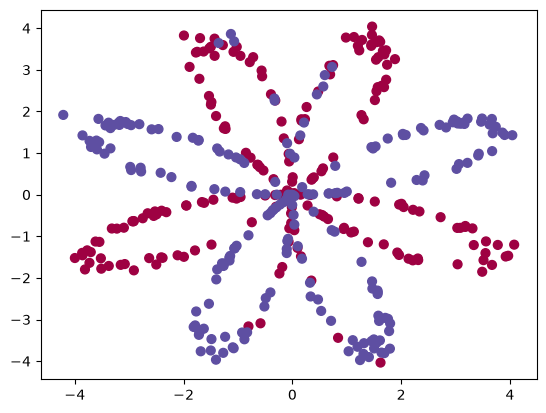

In [5]:
plt.scatter(X[0,:],X[1,:],c=Y,s=40, cmap=plt.cm.Spectral)

In [6]:
shape_X = X.shape
shape_Y = Y.shape

m = shape_X[1]

print('X shape: ',shape_X)
print('Y shape: ',shape_Y)
print('# of examples: ',m)

X shape:  (2, 400)
Y shape:  (1, 400)
# of examples:  400


In [11]:
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T, Y.T)

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundanc

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add an L2 penalty term (used by default);- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy <accuracy_score>` is used... versionchanged:: 1.11 The default will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11.",'warn'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slo

Accuracy of logistic regression: 47 % (percentage of correctly labelled datapoints)


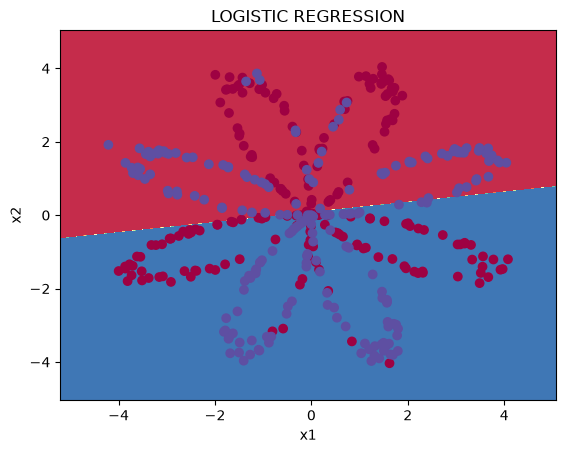

In [14]:
plot_decision_boundary(lambda x: clf.predict(x), X,Y)
plt.title('LOGISTIC REGRESSION')

LR_pred = clf.predict(X.T)
accuracy = float(np.squeeze((np.dot(Y, LR_pred) + np.dot(1 - Y, 1 - LR_pred)) / float(Y.size) * 100))
print(f"Accuracy of logistic regression: {int(accuracy)} % (percentage of correctly labelled datapoints)")

In [17]:
def layer_sizes(X,Y):

    n_x = X.shape[0]
    n_h = 4
    n_y = Y.shape[0]

    return (n_x,n_h,n_y)
    """
    Arguments:
    X -- input dataset of shape (input size, number of examples)
    Y -- labels of shape (output size, number of examples)
    
    Returns:
    n_x -- the size of the input layer
    n_h -- the size of the hidden layer
    n_y -- the size of the output layer
    """

In [21]:
def initialize_parameters(n_x,n_h,n_y):
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y , n_h) * 0.01
    b2 = np.zeros((n_y, 1))

    parameters = {'W1':W1, "b1":b1, "W2":W2, "b2":b2}

    return parameters

In [22]:
def forward_propagation(X,parameters):
    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']

#Hidden Layer

    Z1 = np.dot(W1,X)+b1
    A1 = np.tanh(Z1)

#Output Layer

    Z2 = np.dot(W2,A1)+b2
    A2 = sigmoid(Z2)

    cache = {'Z1': Z1, "A1": A1, "Z2": Z2, 'A2': A2}
    return A2, cache


In [23]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    cost = np.sum(Y * np.log(A2) + (1 - Y) * np.log(1 - A2)) * -1 / m
    cost = np.squeeze(cost)
    return cost


In [24]:
def backward_propagation(parameters,cache,X,Y):
    W1 = parameters['W1']
    W2 = parameters['W2']
    A1 = cache['A1']
    A2 = cache['A2']
    m = X.shape[1]

    # (Output Layer) Gradients

    dZ2 = A2 - Y
    dW2 = np.dot(dZ2, A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    # (Hidden Layer) Gradients

    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1,2))
    dW1 = np.dot(dZ1, X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

In [25]:
def update_parameters(parameters,grads,learning_rate):
    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']
    dW1 = grads['dW1']
    db1 = grads['db1']
    dW2 = grads['dW2']
    db2 = grads['db2']

#  LAYER 1 (Hidden updates)    

    W1 = W1 - (learning_rate * dW1)
    b1 = b1 - (learning_rate * db1)

#   LAYER 2 (Output updates)    

    W2 = W2 - (learning_rate * dW2)
    b2 = b2 - (learning_rate * db2)

    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters

In [26]:
def nn_model(X, Y, n_h, num_iterations=10000, print_cost=False):
    n_x, _, n_y = layer_sizes(X,Y)
    parameters = initialize_parameters(n_x,n_h,n_y)
    for i in range(0,num_iterations):
        A2, cache = forward_propagation(X,parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters,cache, X,Y)
        parameters = update_parameters(parameters, grads, learning_rate=1.2)
        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost}")

    return parameters

